# 01 - Can local velocity predictions generate the whole distribution?

Notebook `00` defined the training arrows. We now fit a small unconditional MLP
and follow its learned field from fresh noise to generated samples. The central
test is visual: a falling training loss is useful, but does it guarantee that
the generated batch covers every mode with the right shape and frequency?

Three clusters form the main experiment used throughout the steering notes. A
circle and eight separated Gaussians appear later as short transfer checks for
curved support and missing modes.

**Time convention:** `t=0` is noise and `t=1` is data.


In [1]:
import sys
from pathlib import Path

NOTES_DIR = Path.cwd()
if not (NOTES_DIR / "toy_notes.py").exists():
    NOTES_DIR = Path("notebooks/toy_data")
sys.path.insert(0, str(NOTES_DIR.resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from toy_notes import *
from notebook_views import *

SEED = 2026
set_seed(SEED)
device = choose_device()
print("device:", device)


device: cuda


## 1. Why train the model ourselves?

A pretrained checkpoint would hide the connection between sampled endpoint
pairs and the velocity loss. This small example lets us see the complete
training rule before using larger pretrained image models.

For each minibatch:

1. sample independent `x_noise` and `x_data`;
2. sample `t` uniformly from `[0,1]`;
3. form `x_t = t*x_data + (1-t)*x_noise`;
4. regress `v_theta(t,x_t)` onto `x_data - x_noise` with mean-squared error.

This is I-CFM. It is not optimal-transport CFM because we do not solve an
optimal coupling between noise and data samples.

**Before you run:** Predict which claim a low minibatch loss supports directly:
accurate sampled training arrows, correct generated mode frequencies, or both.


In [2]:
def train_visible_flow(model, steps):
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-5)
    losses = []
    model.train()

    for step in range(steps):
        x_data, _ = sample_labeled_mixture(1024, device=device)
        x_noise = sample_base(1024, device=device)
        t = torch.rand(1024, device=device)
        x_t = (1 - t[:, None]) * x_noise + t[:, None] * x_data
        target_velocity = x_data - x_noise

        loss = (model(t, x_t) - target_velocity).square().mean()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    model.eval()
    return losses

model, losses, _ = load_or_train_model(device=device, trainer=train_visible_flow)
print("trainable parameters:", sum(p.numel() for p in model.parameters()))


trainable parameters: 34050


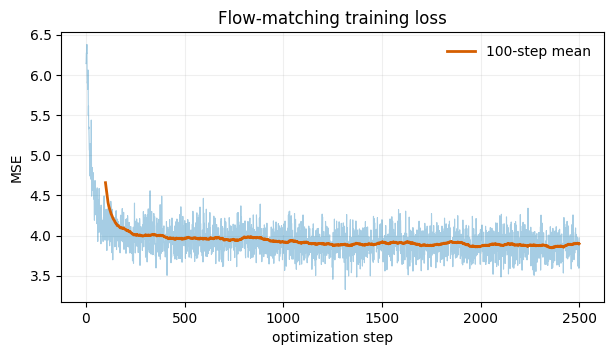

In [3]:
plot_loss_curve(losses, title="Flow-matching training loss")


The loss measures sampled velocity targets. It does not directly count modes
or compare generated endpoints with data, so generation must be checked by
actually integrating the field.

## 2. How does a fitted field become samples?

Once an initial noise batch is fixed, the ODE sampler is deterministic:

$$\frac{dx}{dt}=v_\theta(t,x), \qquad x(0)=x_{noise}.$$

We use Heun's method here. Notebook `02` compares it with Euler and RK4.

**Before you run:** At early times, should particles already be separated by
their eventual destination, or can the partition emerge gradually? Colors in
the snapshot figure will be assigned from final endpoints, after generation.


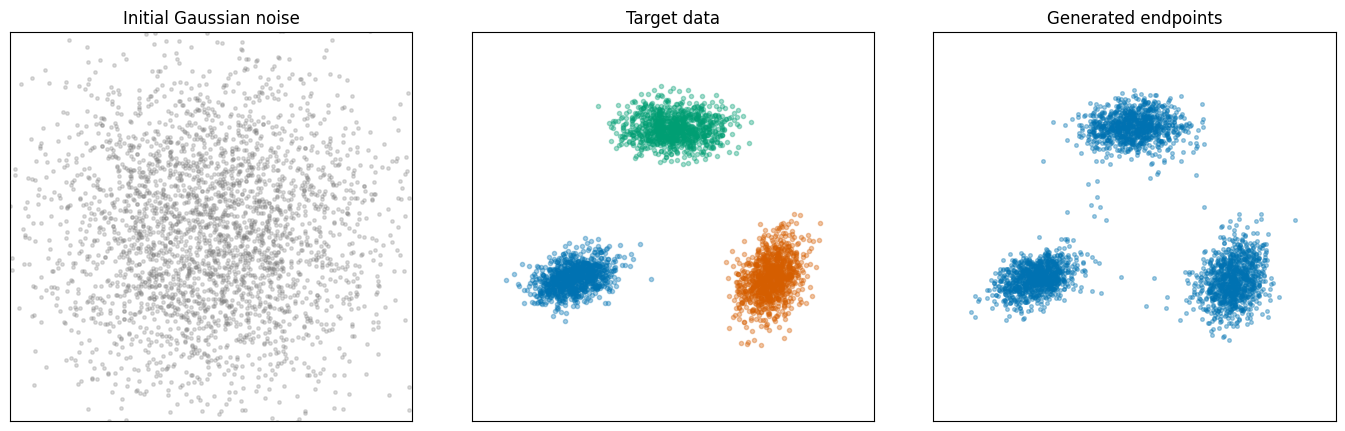

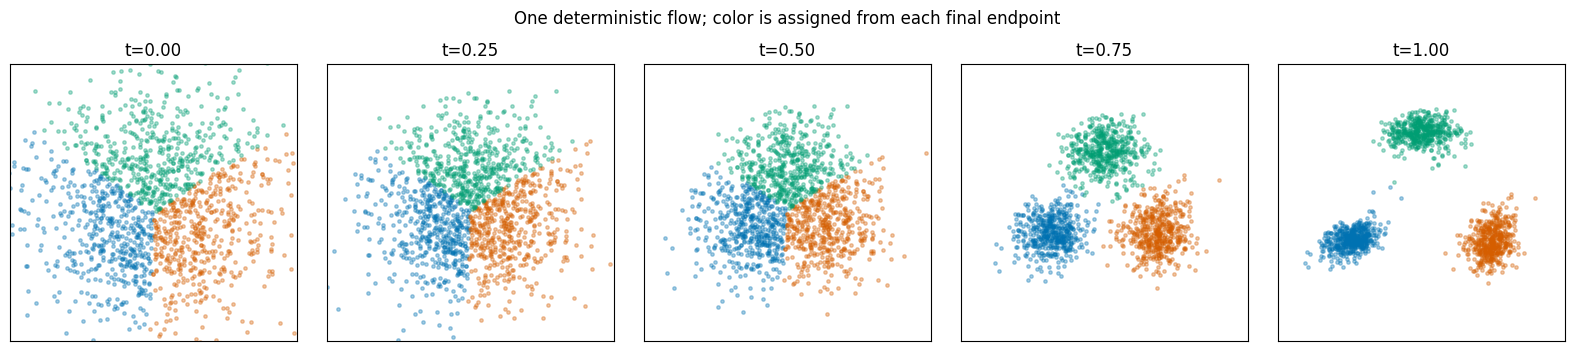

sampling time: 0.183 s


In [4]:
set_seed(SEED + 10)
x0_eval = sample_base(3000, device=device)
trajectory, sample_seconds = timed_sample(base_velocity(model), x0_eval, steps=80, method="heun")
generated = trajectory[-1].to(device)
target, target_labels = sample_labeled_mixture(3000, device=device)

plot_flow_endpoints(x0_eval, target, target_labels, generated)
plot_flow_snapshots(trajectory, generated, target, target_labels)
print(f"sampling time: {sample_seconds:.3f} s")


In [5]:
diagnostics = pd.DataFrame(flow_endpoint_diagnostics(generated, target, target_labels))
display(diagnostics.round(4))


,diagnostic,value
0,empirical matching distance to full target,0.253774
1,generated class balance max error,0.001
2,smallest generated mode fraction,0.332333
3,all samples finite,True


### Why use an empirical Wasserstein matching distance in addition to a plot?

The time snapshots show one learned map, while the endpoint panel reveals
whether its final distribution resembles the data. A class rate or mean checks
only one property. The empirical Wasserstein matching below finds a minimum-cost
one-to-one matching between equal-size sample subsets and reports their mean
distance. It is a finite-sample diagnostic, not the unknown population
population Wasserstein distance.

The lines below make the definition literal. Lower is better. We still inspect
mode coverage and spread because one scalar cannot diagnose every failure.


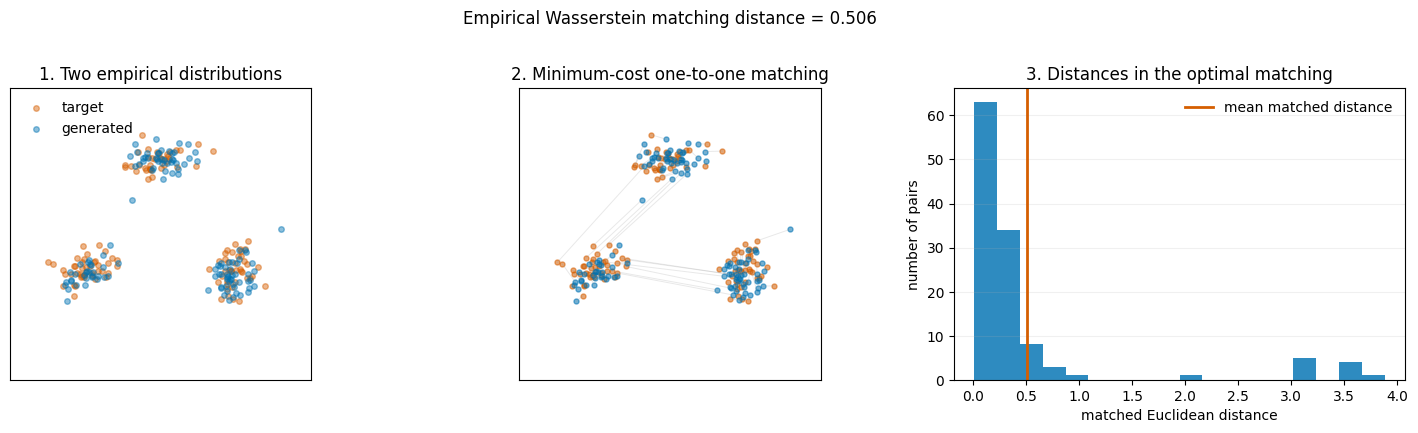

In [6]:
_ = plot_wasserstein_matching(generated, target)


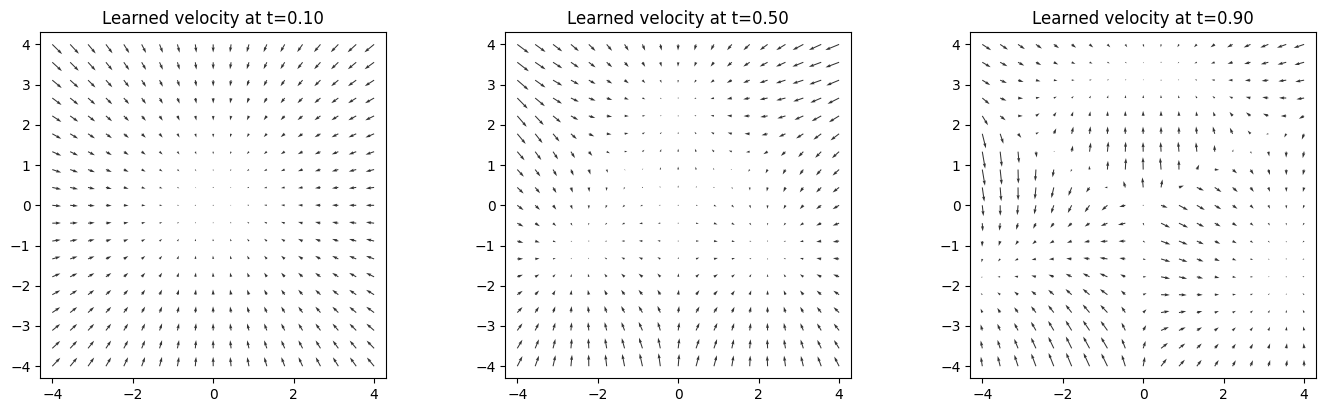

In [7]:
plot_velocity_field(model, device)


## 3. Transfer check: does the same rule learn a curve?

Three Gaussian clusters could leave the impression that flow matching only
learns a few destination centers. A noisy circle is a stricter visual test: it
has continuously many valid endpoints and a thin curved support. We train a
separate unconditional model and ask whether it forms the ring without leaving
large angular gaps.

**Before you run:** A low radial error is not enough to reproduce a circle.
What additional failure would appear as a large empty arc?


In [8]:
circle = run_flow_case(
    load_or_train_circle_model, sample_noisy_circle,
    device=device, seed=SEED + 71,
)


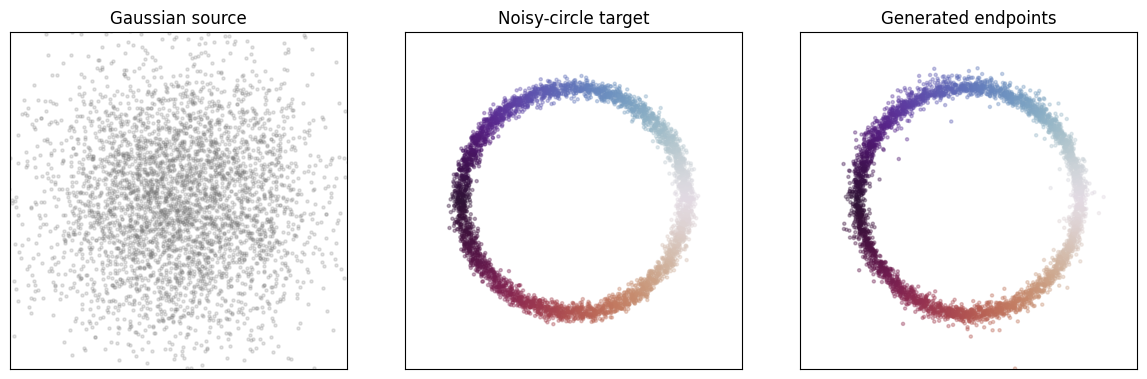

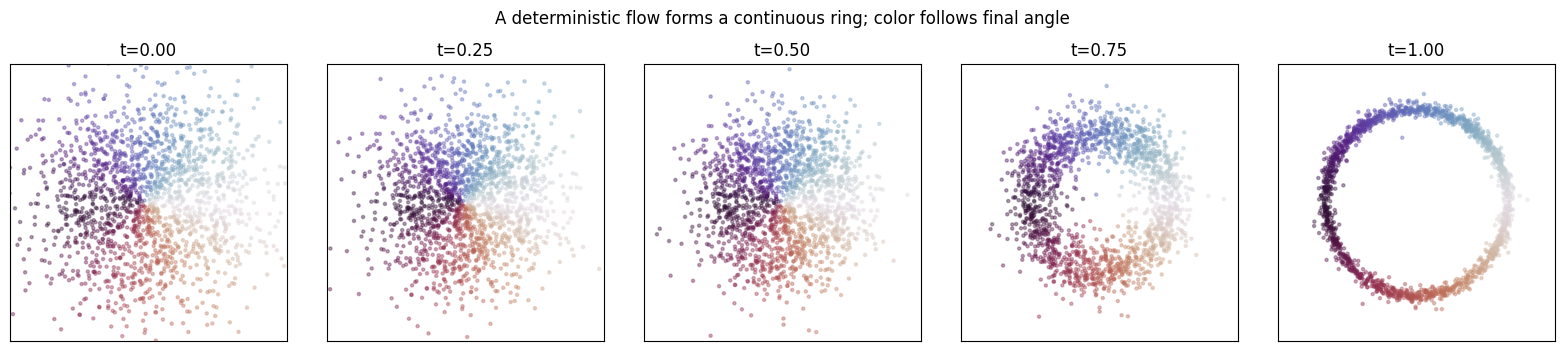

In [9]:
plot_circle_flow(circle)


In [10]:
circle_metrics = pd.DataFrame(circle_flow_metrics(circle))
display(circle_metrics[circle_metrics["diagnostic"].isin([
    "generated radial MAE",
    "angular occupancy total variation",
    "generated-to-target empirical matching distance",
])].round(4))


,diagnostic,value
2,generated radial MAE,0.0968
3,angular occupancy total variation,0.0332
4,generated-to-target empirical matching distance,0.3925


## 4. Transfer check: can one flow cover eight modes?

The three-class model is kept for the steering notebooks because its labels are
easy to discuss, while the circle tests continuous curved geometry. Eight narrow
components expose a different failure mode: a model can omit destinations or
assign them the wrong amount of probability. This is still learned I-CFM; no
destination center is used by the sampler.

We color each particle by the component nearest to its **final** endpoint, then
trace the same particle backward through stored time slices. The colors are for
reading the map after sampling; the model never receives them.

**Before you run:** Could a model produce convincing points near seven centers
and still have a moderate average distance to the full target? Look for both
coverage and occupancy in the result.


In [11]:
balanced_labels = torch.arange(8, device=device).repeat_interleave(512)
eight_modes = run_flow_case(
    load_or_train_eight_gaussian_model,
    sample_eight_gaussians,
    device=device,
    seed=SEED + 81,
    sampler_kwargs={"labels": balanced_labels},
)


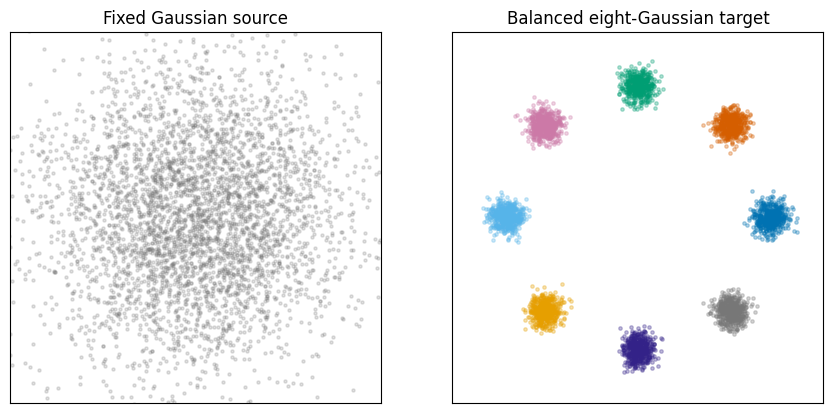

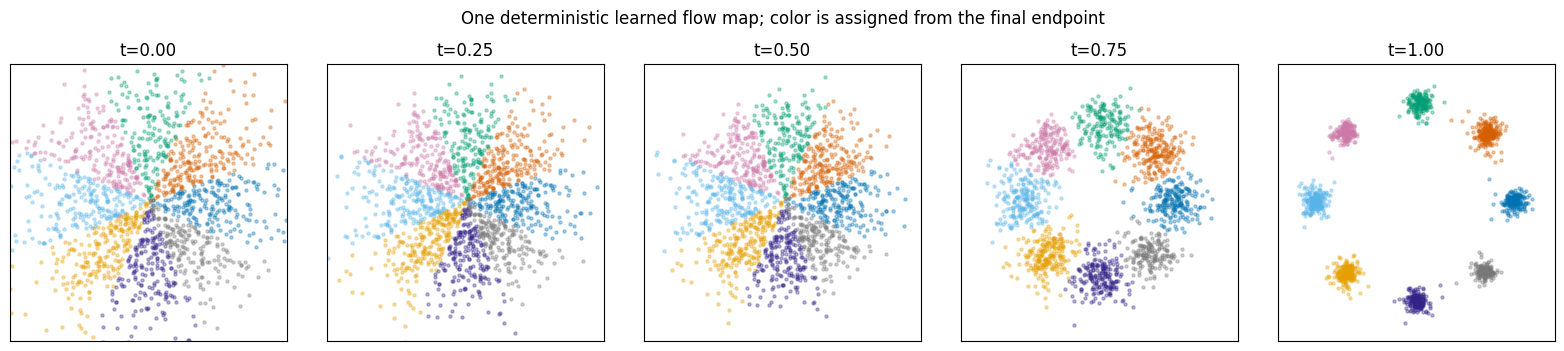

In [12]:
plot_eight_gaussian_flow(eight_modes)


In [13]:
eight_summary, per_mode = eight_gaussian_metrics(eight_modes)
display(pd.DataFrame(eight_summary).round(4))


,diagnostic,value
0,modes with at least 5% generated mass,8
1,occupancy total variation from uniform,0.017578
2,generated-to-target empirical matching distance,0.259482
3,generated/source distance ratio,0.209546
4,mean normalized centroid error,0.171227
5,median within-mode trace ratio,1.035701
6,all endpoints finite,True


The snapshot figure shows **where the learned ODE sends regions of the initial
Gaussian**, while the diagnostics describe mode coverage, occupancy, and
within-mode spread. No single plot or scalar captures every mismatch between
the generated and target distributions.


## What carries forward?

The circle and eight-mode cases are transfer checks, not new storylines. They
show why we inspect trajectories, coverage, occupancy, and spread rather than
trusting one training loss or one distance.

The remaining toy notes return to the same three-cluster checkpoint. Notebook
`02` holds that model and its initial noise fixed, then asks how much of a
generated endpoint is determined by the learned field and how much by the
numerical solver.

**Change one thing:** In the main sampling cell, replace `steps=80` with
`steps=12` and rerun only the endpoint and snapshot cells. The model is
unchanged; any new distortion comes from following the same field more
coarsely.
